In [173]:
# Importação das bibliotecas

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.optimize import curve_fit

from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor

import statsmodels.formula.api as smf

In [174]:
# Importação dos dados

df = pd.read_excel("data/dados.xlsx")
df["Idade_num"] = df["Idade"].str.replace(" meses","").astype(int)

df.head()

,Idade,Árvore,DAP,H,Volume,Idade_num
0,36 meses,Árvore1,7.6,4.7,0.017514,36
1,36 meses,Árvore2,7.4,4.3,0.008274,36
2,36 meses,Árvore3,7.6,3.9,0.011789,36
3,36 meses,Árvore4,9.4,5.4,0.028859,36
4,36 meses,Árvore5,9.3,6.1,0.022332,36


In [175]:
# Estatística descritiva

df.describe()

,DAP,H,Volume,Idade_num
count,672.000000,672.000000,672.000000,672.000000
mean,12.047609,9.194107,0.083602,59.785714
std,4.894081,3.721439,0.079140,14.336864
min,1.100000,1.500000,0.000435,36.000000
25%,8.800000,6.400000,0.025726,48.000000
50%,12.000000,9.150000,0.058092,60.000000
75%,15.025000,11.900000,0.117383,72.000000
max,27.692960,21.800000,0.425937,84.000000


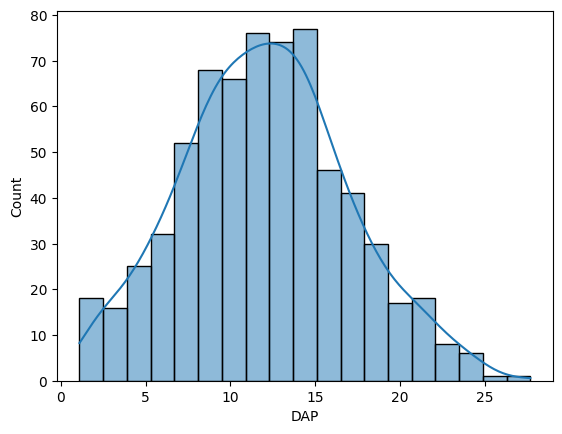

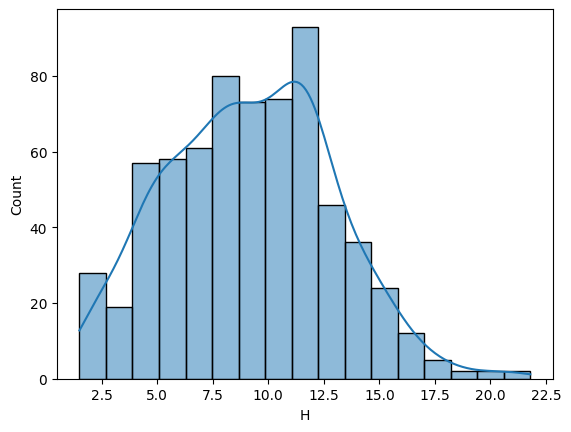

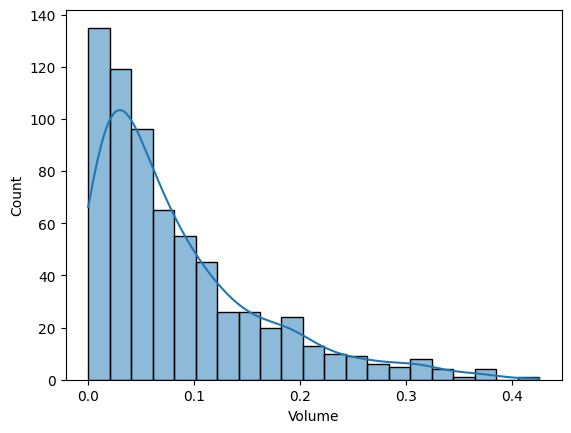

In [176]:
# Análise exploratória

sns.histplot(df["DAP"], kde=True)
plt.show()

sns.histplot(df["H"], kde=True)
plt.show()

sns.histplot(df["Volume"], kde=True)
plt.show()

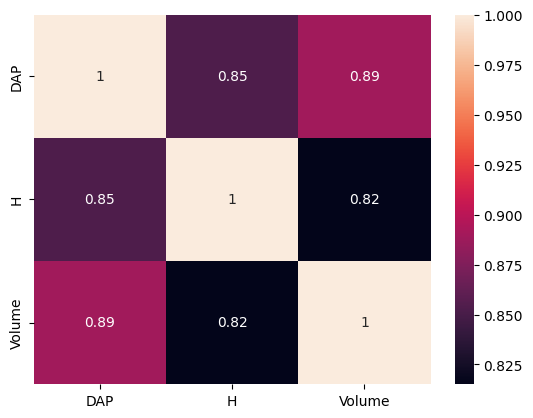

In [177]:
# Correlação entre as variáveis

corr = df[['DAP','H','Volume']].corr()

sns.heatmap(corr, annot=True)
plt.show()

In [178]:
# Médias por idade
growth_mean = df.groupby("Idade_num").mean(numeric_only=True)
growth_mean

,DAP,H,Volume
Idade_num,,,
36,8.841379,5.374713,0.026737
48,10.037821,7.596154,0.042175
60,11.530726,8.907821,0.073266
72,14.091567,11.063956,0.124476
84,16.650416,13.495588,0.169206


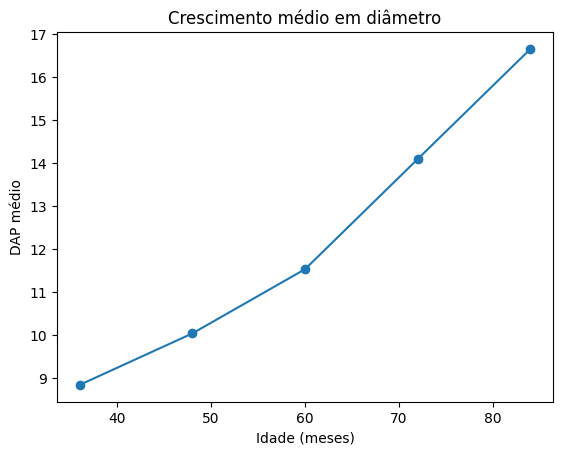

In [179]:
# DAP x Idade

plt.plot(growth_mean.index, growth_mean["DAP"], marker="o")
plt.xlabel("Idade (meses)")
plt.ylabel("DAP médio")
plt.title("Crescimento médio em diâmetro")
plt.show()

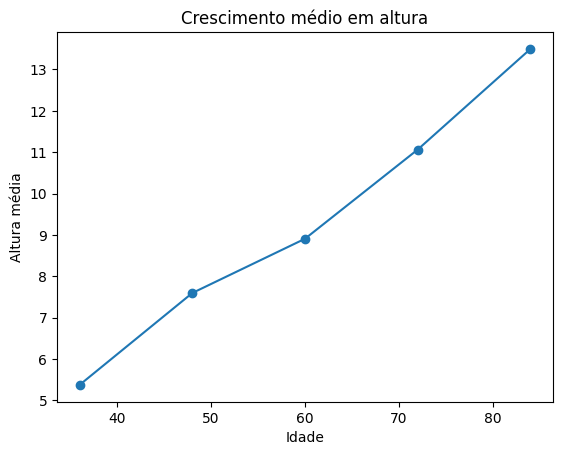

In [180]:
# Altura x Idade

plt.plot(growth_mean.index, growth_mean["H"], marker="o")
plt.xlabel("Idade")
plt.ylabel("Altura média")
plt.title("Crescimento médio em altura")
plt.show()

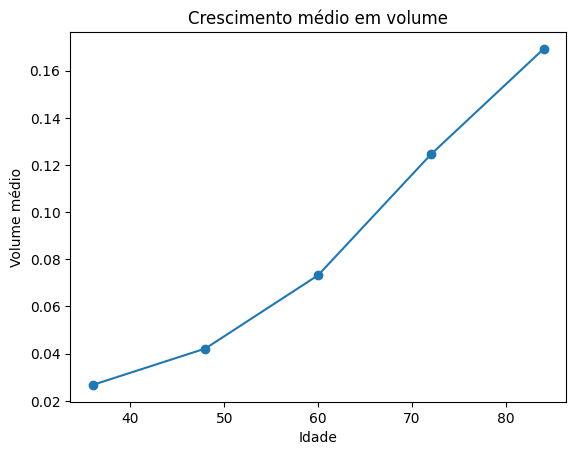

In [181]:
# Volume x Idade

plt.plot(growth_mean.index, growth_mean["Volume"], marker="o")
plt.xlabel("Idade")
plt.ylabel("Volume médio")
plt.title("Crescimento médio em volume")
plt.show()

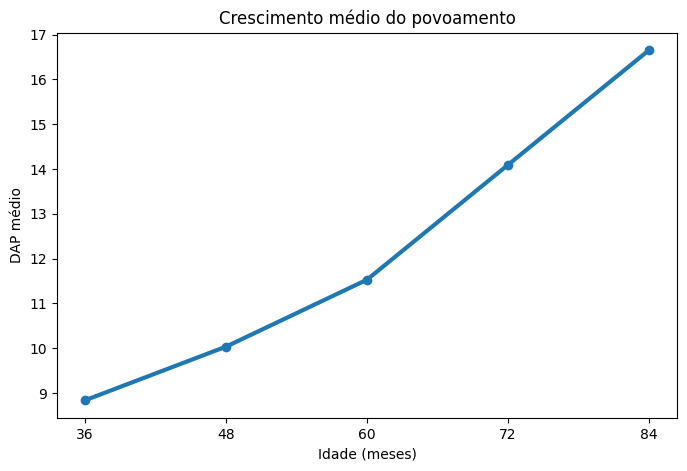

In [182]:
# Gráfico de crescimento por povoamento (DAP)

growth_mean = df.groupby("Idade_num").mean(numeric_only=True)

plt.figure(figsize=(8,5))

plt.plot(growth_mean.index, growth_mean["DAP"], marker="o", linewidth=3)
plt.xlabel("Idade (meses)")
plt.ylabel("DAP médio")
plt.title("Crescimento médio do povoamento")
plt.xticks([36,48,60,72,84])

plt.show()

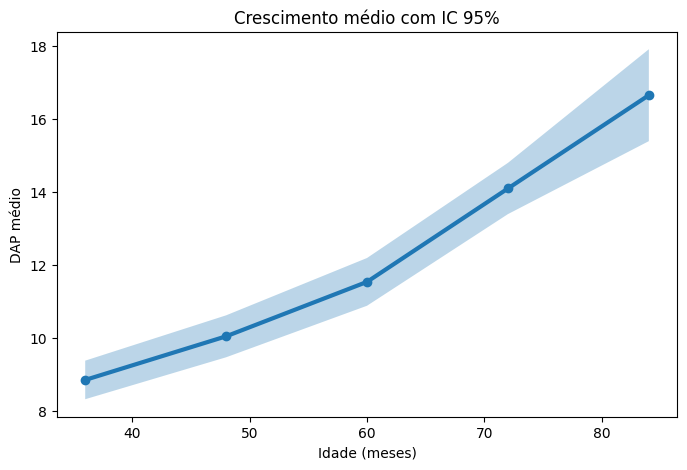

In [183]:
# Crescimento médio com intervalo de confiança de 95%

growth_stats = df.groupby("Idade_num")["DAP"].agg(["mean","std","count"])
growth_stats["se"] = growth_stats["std"] / np.sqrt(growth_stats["count"])
growth_stats["ci"] = 1.96 * growth_stats["se"]

plt.figure(figsize=(8,5))

plt.plot(growth_stats.index, growth_stats["mean"], marker="o", linewidth=3)

plt.fill_between(
    growth_stats.index,
    growth_stats["mean"] - growth_stats["ci"],
    growth_stats["mean"] + growth_stats["ci"],
    alpha=0.3
)
plt.xlabel("Idade (meses)")
plt.ylabel("DAP médio")
plt.title("Crescimento médio com IC 95%")

plt.show()

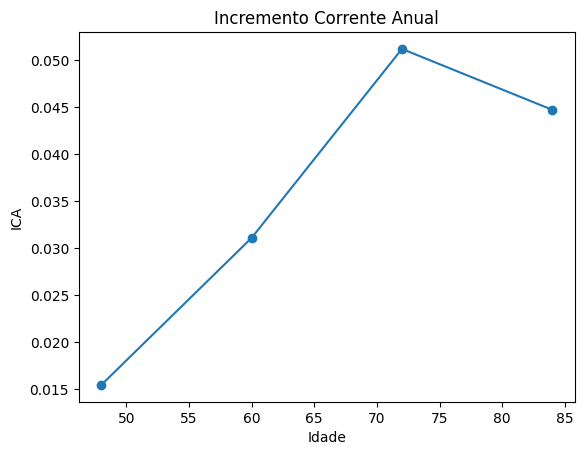

In [184]:
# Incremento Corrente Anual (ICA)

growth_mean["ICA"] = growth_mean["Volume"].diff()

plt.plot(growth_mean.index, growth_mean["ICA"], marker="o")
plt.xlabel("Idade")
plt.ylabel("ICA")
plt.title("Incremento Corrente Anual")

plt.show()

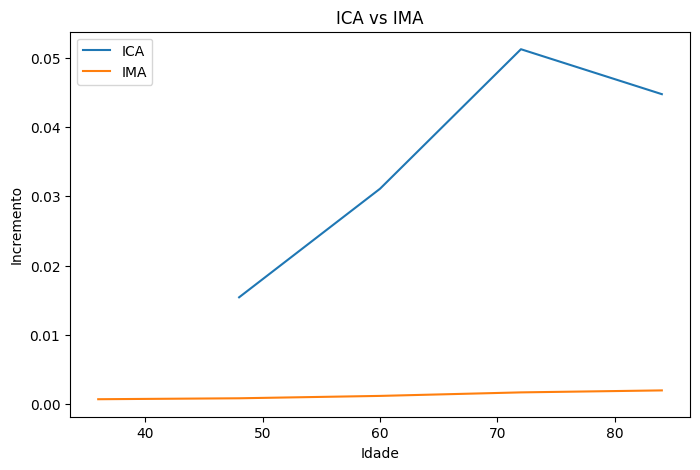

In [185]:
# Incremento Médio Anual (IMA)

growth_mean["IMA"] = growth_mean["Volume"] / growth_mean.index

plt.figure(figsize=(8,5))
plt.plot(growth_mean.index, growth_mean["ICA"], label="ICA")
plt.plot(growth_mean.index, growth_mean["IMA"], label="IMA")
plt.legend()
plt.xlabel("Idade")
plt.ylabel("Incremento")
plt.title("ICA vs IMA")

plt.show()

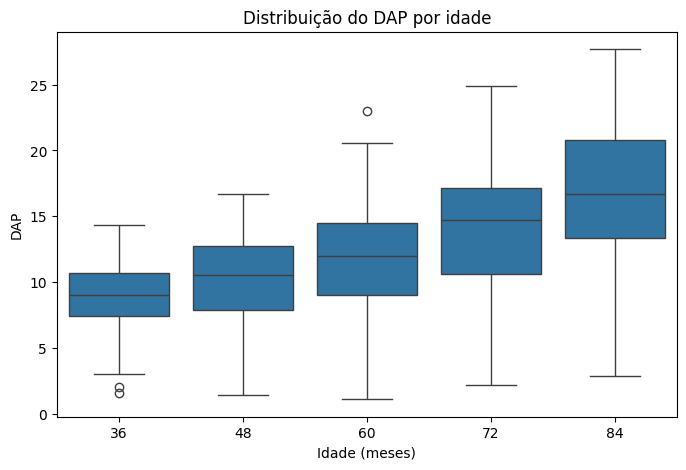

In [186]:
# Boxplot de DAP por idade

plt.figure(figsize=(8,5))

sns.boxplot(x="Idade_num", y="DAP", data=df)

plt.xlabel("Idade (meses)")
plt.ylabel("DAP")

plt.title("Distribuição do DAP por idade")

plt.show()

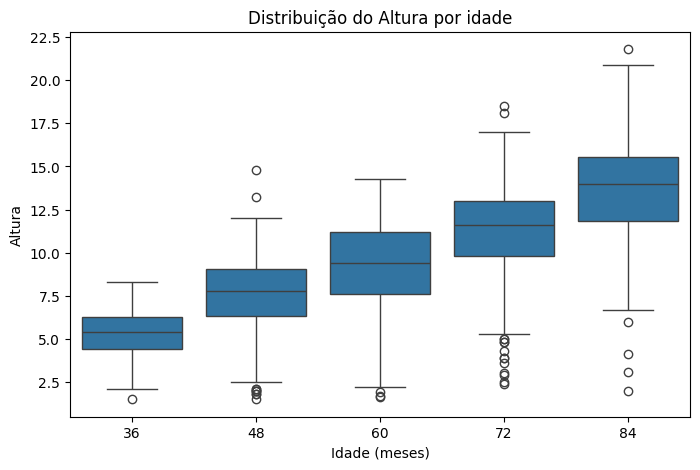

In [187]:
# Boxplot de Altura por idade

plt.figure(figsize=(8,5))

sns.boxplot(x="Idade_num", y="H", data=df)

plt.xlabel("Idade (meses)")
plt.ylabel("Altura")

plt.title("Distribuição do Altura por idade")

plt.show()

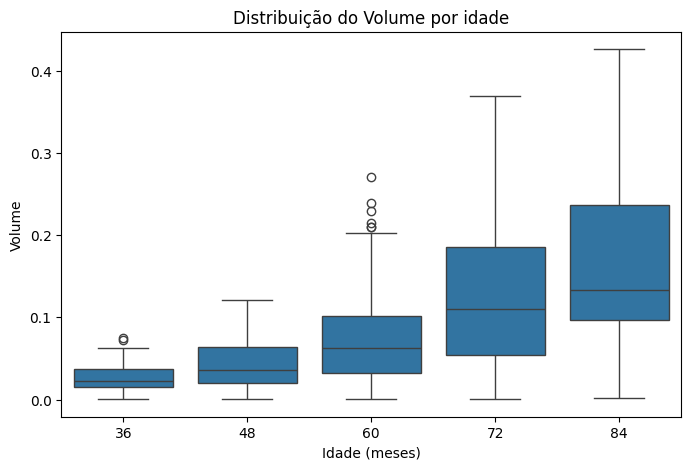

In [188]:
# Boxplot de Volume por idade

plt.figure(figsize=(8,5))

sns.boxplot(x="Idade_num", y="Volume", data=df)

plt.xlabel("Idade (meses)")
plt.ylabel("Volume")

plt.title("Distribuição do Volume por idade")

plt.show()

In [189]:
# Definição dos modelos biológicos de crescimento

# Logístico
def logistic(t, a, b, c):
    return a / (1 + b * np.exp(-c*t))

# Gompertz
def gompertz(t, a, b, c):
    return a * np.exp(-b * np.exp(-c*t))

# Richards
def richards(t, a, b, c):
    return a * np.maximum(1 - np.exp(-b*t), 1e-6)**c

In [190]:
# Ajuste dos modelos biológicos de crescimento diamétrico

idade = growth_mean.index.values
dap = growth_mean["DAP"].values

params_log, _ = curve_fit(
    logistic,
    idade,
    dap,
    p0=[max(dap), 1, 0.05]
)

params_gom, _ = curve_fit(
    gompertz,
    idade,
    dap,
    p0=[max(dap), 1, 0.05],
    bounds=(0, [50, 10, 1]),
    maxfev=10000
)

params_rich, _ = curve_fit(
    richards,
    idade,
    dap,
    p0=[max(dap), 0.05, 1],
    bounds=([0,0,0],[50,1,5]),
    maxfev=20000
)

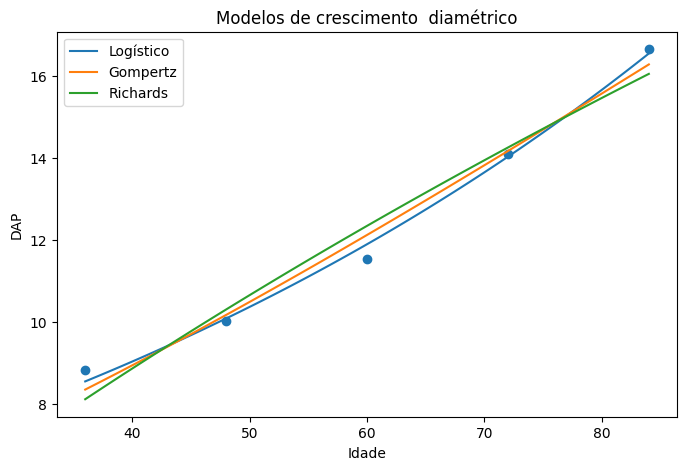

In [191]:
# Comparação visual das curvas

t = np.linspace(min(idade), max(idade), 100)

plt.figure(figsize=(8,5))
plt.scatter(idade, dap)
plt.plot(t, logistic(t, *params_log), label="Logístico")
plt.plot(t, gompertz(t, *params_gom), label="Gompertz")
plt.plot(t, richards(t, *params_rich), label="Richards")
plt.legend()
plt.xlabel("Idade")
plt.ylabel("DAP")
plt.title("Modelos de crescimento  diamétrico")

plt.show()

In [192]:
'''
Preparando dataset de treino e teste para os algoritmos de machine learning
para o crescimento diamétrico (70/30)
'''

X = df[["Idade_num"]]
y = df["DAP"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42
)

In [193]:
# Random Forest

rf = RandomForestRegressor(n_estimators=500)
rf.fit(X_train, y_train)
pred_rf = rf.predict(X_test)

In [194]:
# XGBoost

xgb = XGBRegressor(n_estimators=500)
xgb.fit(X_train, y_train)
pred_xgb = xgb.predict(X_test)

In [195]:
# Rede Neural

mlp = MLPRegressor(hidden_layer_sizes=(50,50), max_iter=5000)
mlp.fit(X_train, y_train)
pred_mlp = mlp.predict(X_test)

In [196]:
# SVM

svm = SVR()
svm.fit(X_train, y_train)
pred_svm = svm.predict(X_test)

In [197]:
# Realizar a avaliação

def avaliar(y_true, pred):
    r2 = r2_score(y_true, pred)
    rmse = np.sqrt(mean_squared_error(y_true, pred))
    mae = mean_absolute_error(y_true, pred)

    return r2, rmse, mae

r2_rf, rmse_rf, mae_rf = avaliar(y_test, pred_rf)
r2_xgb, rmse_xgb, mae_xgb = avaliar(y_test, pred_xgb)
r2_mlp, rmse_mlp, mae_mlp = avaliar(y_test, pred_mlp)
r2_svm, rmse_svm, mae_svm = avaliar(y_test, pred_svm)

In [198]:
# Avaliação dos modelos biológicos para crescimento diamétrico

pred_log_test = logistic(X_test["Idade_num"], *params_log)
pred_gom_test = gompertz(X_test["Idade_num"], *params_gom)
pred_rich_test = richards(X_test["Idade_num"], *params_rich)

r2_log, rmse_log, mae_log = avaliar(y_test, pred_log_test)
r2_gom, rmse_gom, mae_gom = avaliar(y_test, pred_gom_test)
r2_rich, rmse_rich, mae_rich = avaliar(y_test, pred_rich_test)

In [199]:
# Tabela de comparação geral do crescimento diamétrico

results = pd.DataFrame({

    "Modelo":[
        "Logístico",
        "Gompertz",
        "Richards",
        "Random Forest",
        "XGBoost",
        "Neural Network",
        "SVM"
    ],

    "R2":[
        r2_log,
        r2_gom,
        r2_rich,
        r2_rf,
        r2_xgb,
        r2_mlp,
        r2_svm
    ],

    "RMSE":[
        rmse_log,
        rmse_gom,
        rmse_rich,
        rmse_rf,
        rmse_xgb,
        rmse_mlp,
        rmse_svm
    ],

    "MAE":[
        mae_log,
        mae_gom,
        mae_rich,
        mae_rf,
        mae_xgb,
        mae_mlp,
        mae_svm
    ]
})

results.sort_values("RMSE")

,Modelo,R2,RMSE,MAE
0,Logístico,0.302075,4.264108,3.332927
1,Gompertz,0.298302,4.275619,3.337519
4,XGBoost,0.297721,4.277389,3.344090
3,Random Forest,0.297146,4.279139,3.346100
5,Neural Network,0.293910,4.288978,3.371929
2,Richards,0.291448,4.296451,3.349114
6,SVM,0.280501,4.329512,3.354383


In [200]:
# Geração de curvas para todos os modelos de crescimento diamétrico

t = np.linspace(df["Idade_num"].min(), df["Idade_num"].max(), 100)
t_df = pd.DataFrame({"Idade_num": t})

pred_rf_curve = rf.predict(t_df)
pred_xgb_curve = xgb.predict(t_df)
pred_mlp_curve = mlp.predict(t_df)
pred_svm_curve = svm.predict(t_df)

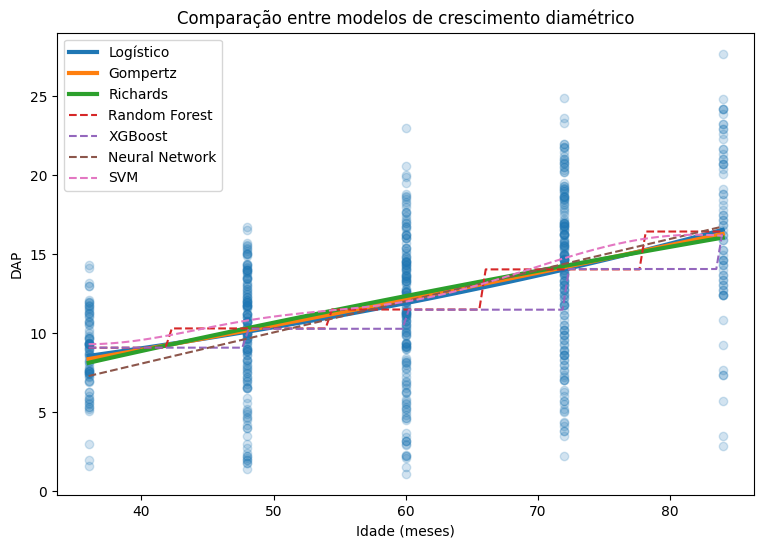

In [201]:
# Gráfico de comparação dos modelos de crescimento diamétrico

plt.figure(figsize=(9,6))

# dados observados
plt.scatter(df["Idade_num"], df["DAP"], alpha=0.2)

# modelos biológicos
plt.plot(t, logistic(t, *params_log), label="Logístico", linewidth=3)
plt.plot(t, gompertz(t, *params_gom), label="Gompertz", linewidth=3)
plt.plot(t, richards(t, *params_rich), label="Richards", linewidth=3)

# modelos de IA
plt.plot(t, pred_rf_curve, label="Random Forest", linestyle="--")
plt.plot(t, pred_xgb_curve, label="XGBoost", linestyle="--")
plt.plot(t, pred_mlp_curve, label="Neural Network", linestyle="--")
plt.plot(t, pred_svm_curve, label="SVM", linestyle="--")

plt.xlabel("Idade (meses)")
plt.ylabel("DAP")

plt.title("Comparação entre modelos de crescimento diamétrico")

plt.legend()

plt.show()

In [202]:
# ANOVA

import statsmodels.api as sm
from statsmodels.formula.api import ols

modelo = ols('DAP ~ C(Idade_num)', data=df).fit()

anova = sm.stats.anova_lm(modelo)

anova

,df,sum_sq,mean_sq,F,PR(>F)
C(Idade_num),4.0,3773.287327,943.321832,51.160245,1.388752e-37
Residual,667.0,12298.527065,18.438571,NaN,NaN


In [203]:
# Calcular a proporção da variância explicada

ss_idade = anova["sum_sq"]["C(Idade_num)"]
ss_total = anova["sum_sq"].sum()

variancia_explicada = ss_idade / ss_total

variancia_explicada

np.float64(0.23477668636348142)

In [204]:
'''
Preparando dataset de treino e teste para os algoritmos de machine learning
para o crescimento em altura (70/30)
'''

X = df[["Idade_num"]]
y = df["H"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42
)

In [205]:
# Random Forest

rf = RandomForestRegressor(n_estimators=500)
rf.fit(X_train, y_train)
pred_rf = rf.predict(X_test)

In [206]:
# XGBoost

xgb = XGBRegressor(n_estimators=500)
xgb.fit(X_train, y_train)
pred_xgb = xgb.predict(X_test)

In [207]:
# Rede Neural

mlp = MLPRegressor(hidden_layer_sizes=(50,50), max_iter=5000)
mlp.fit(X_train, y_train)
pred_mlp = mlp.predict(X_test)

In [208]:
# SVM

svm = SVR()
svm.fit(X_train, y_train)
pred_svm = svm.predict(X_test)

In [209]:
# Realizar a avaliação

r2_rf, rmse_rf, mae_rf = avaliar(y_test, pred_rf)
r2_xgb, rmse_xgb, mae_xgb = avaliar(y_test, pred_xgb)
r2_mlp, rmse_mlp, mae_mlp = avaliar(y_test, pred_mlp)
r2_svm, rmse_svm, mae_svm = avaliar(y_test, pred_svm)

In [210]:
# Ajuste dos modelos biológicos de crescimento em altura

idade = growth_mean.index.values
h = growth_mean["H"].values

params_log, _ = curve_fit(
    logistic,
    idade,
    h,
    p0=[max(h), 1, 0.05]
)

params_gom, _ = curve_fit(
    gompertz,
    idade,
    h,
    p0=[max(h), 1, 0.05],
    bounds=(0, [50, 10, 1]),
    maxfev=10000
)

params_rich, _ = curve_fit(
    richards,
    idade,
    h,
    p0=[max(h), 0.05, 1],
    bounds=([0,0,0],[50,1,5]),
    maxfev=20000
)

In [211]:
# Avaliação dos modelos biológicos para crescimento em altura

pred_log_test = logistic(X_test["Idade_num"], *params_log)
pred_gom_test = gompertz(X_test["Idade_num"], *params_gom)
pred_rich_test = richards(X_test["Idade_num"], *params_rich)

r2_log, rmse_log, mae_log = avaliar(y_test, pred_log_test)
r2_gom, rmse_gom, mae_gom = avaliar(y_test, pred_gom_test)
r2_rich, rmse_rich, mae_rich = avaliar(y_test, pred_rich_test)

In [212]:
# Tabela de comparação geral do crescimento em altura

results = pd.DataFrame({

    "Modelo":[
        "Logístico",
        "Gompertz",
        "Richards",
        "Random Forest",
        "XGBoost",
        "Neural Network",
        "SVM"
    ],

    "R2":[
        r2_log,
        r2_gom,
        r2_rich,
        r2_rf,
        r2_xgb,
        r2_mlp,
        r2_svm
    ],

    "RMSE":[
        rmse_log,
        rmse_gom,
        rmse_rich,
        rmse_rf,
        rmse_xgb,
        rmse_mlp,
        rmse_svm
    ],

    "MAE":[
        mae_log,
        mae_gom,
        mae_rich,
        mae_rf,
        mae_xgb,
        mae_mlp,
        mae_svm
    ]
})

results.sort_values("RMSE")

,Modelo,R2,RMSE,MAE
0,Logístico,0.501194,2.739917,2.040346
1,Gompertz,0.500927,2.740652,2.035454
2,Richards,0.497217,2.750819,2.028861
3,Random Forest,0.495450,2.755647,2.059090
4,XGBoost,0.495106,2.756587,2.061841
5,Neural Network,0.493375,2.761309,2.049170
6,SVM,0.481421,2.793697,2.050999


In [213]:
# Geração de curvas para todos os modelos de crescimento em altura

t = np.linspace(df["Idade_num"].min(), df["Idade_num"].max(), 100)
t_df = pd.DataFrame({"Idade_num": t})

pred_rf_curve = rf.predict(t_df)
pred_xgb_curve = xgb.predict(t_df)
pred_mlp_curve = mlp.predict(t_df)
pred_svm_curve = svm.predict(t_df)

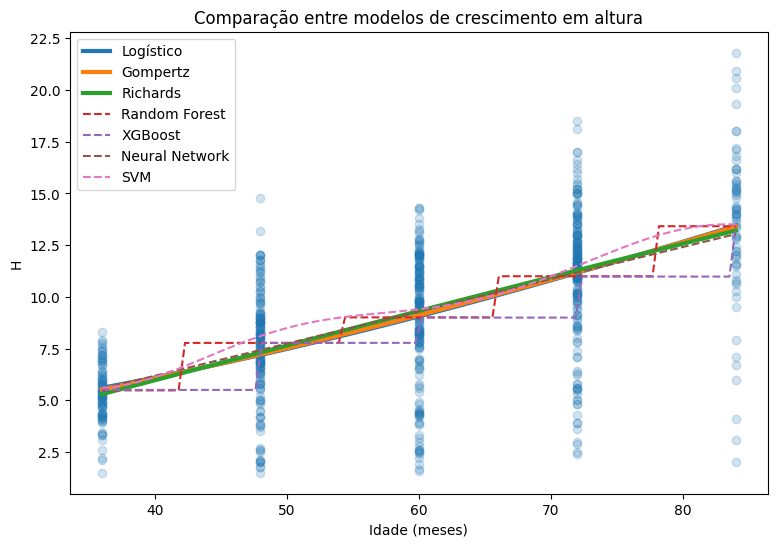

In [214]:
# Gráfico de comparação dos modelos de crescimento diamétrico

plt.figure(figsize=(9,6))

# dados observados
plt.scatter(df["Idade_num"], df["H"], alpha=0.2)

# modelos biológicos
plt.plot(t, logistic(t, *params_log), label="Logístico", linewidth=3)
plt.plot(t, gompertz(t, *params_gom), label="Gompertz", linewidth=3)
plt.plot(t, richards(t, *params_rich), label="Richards", linewidth=3)

# modelos de IA
plt.plot(t, pred_rf_curve, label="Random Forest", linestyle="--")
plt.plot(t, pred_xgb_curve, label="XGBoost", linestyle="--")
plt.plot(t, pred_mlp_curve, label="Neural Network", linestyle="--")
plt.plot(t, pred_svm_curve, label="SVM", linestyle="--")

plt.xlabel("Idade (meses)")
plt.ylabel("H")

plt.title("Comparação entre modelos de crescimento em altura")

plt.legend()

plt.show()

In [215]:
# ANOVA
modelo = ols('H ~ C(Idade_num)', data=df).fit()

anova = sm.stats.anova_lm(modelo)

anova

,df,sum_sq,mean_sq,F,PR(>F)
C(Idade_num),4.0,3576.665326,894.166331,104.338713,5.346814e-69
Residual,667.0,5716.084939,8.569842,NaN,NaN


In [216]:
# Calcular a proporção da variância explicada

ss_idade = anova["sum_sq"]["C(Idade_num)"]
ss_total = anova["sum_sq"].sum()

variancia_explicada = ss_idade / ss_total

variancia_explicada

np.float64(0.3848877053663694)

In [217]:
'''
Preparando dataset de treino e teste para os algoritmos de machine learning
para o crescimento volumétrico (70/30)
'''

X = df[["Idade_num"]]
y = df["Volume"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42
)

In [218]:
# Random Forest

rf = RandomForestRegressor(n_estimators=500)
rf.fit(X_train, y_train)
pred_rf = rf.predict(X_test)

In [219]:
# XGBoost

xgb = XGBRegressor(n_estimators=500)
xgb.fit(X_train, y_train)
pred_xgb = xgb.predict(X_test)

In [220]:
# Rede Neural

mlp = MLPRegressor(hidden_layer_sizes=(50,50), max_iter=5000)
mlp.fit(X_train, y_train)
pred_mlp = mlp.predict(X_test)

In [221]:
# SVM

svm = SVR()
svm.fit(X_train, y_train)
pred_svm = svm.predict(X_test)

In [222]:
# Realizar a avaliação

r2_rf, rmse_rf, mae_rf = avaliar(y_test, pred_rf)
r2_xgb, rmse_xgb, mae_xgb = avaliar(y_test, pred_xgb)
r2_mlp, rmse_mlp, mae_mlp = avaliar(y_test, pred_mlp)
r2_svm, rmse_svm, mae_svm = avaliar(y_test, pred_svm)

In [223]:
# Ajuste dos modelos biológicos de crescimento volumétrico

idade = growth_mean.index.values
volume = growth_mean["Volume"].values

params_log, _ = curve_fit(
    logistic,
    idade,
    volume,
    p0=[max(volume), 1, 0.05]
)

params_gom, _ = curve_fit(
    gompertz,
    idade,
    volume,
    p0=[max(volume), 1, 0.05],
    bounds=(0, [50, 10, 1]),
    maxfev=10000
)

params_rich, _ = curve_fit(
    richards,
    idade,
    volume,
    p0=[max(volume), 0.05, 1],
    bounds=([0,0,0],[50,1,5]),
    maxfev=20000
)

In [224]:
# Avaliação dos modelos biológicos para crescimento volumétrico

pred_log_test = logistic(X_test["Idade_num"], *params_log)
pred_gom_test = gompertz(X_test["Idade_num"], *params_gom)
pred_rich_test = richards(X_test["Idade_num"], *params_rich)

r2_log, rmse_log, mae_log = avaliar(y_test, pred_log_test)
r2_gom, rmse_gom, mae_gom = avaliar(y_test, pred_gom_test)
r2_rich, rmse_rich, mae_rich = avaliar(y_test, pred_rich_test)

In [225]:
# Tabela de comparação geral do crescimento em volumétrico

results = pd.DataFrame({

    "Modelo":[
        "Logístico",
        "Gompertz",
        "Richards",
        "Random Forest",
        "XGBoost",
        "Neural Network",
        "SVM"
    ],

    "R2":[
        r2_log,
        r2_gom,
        r2_rich,
        r2_rf,
        r2_xgb,
        r2_mlp,
        r2_svm
    ],

    "RMSE":[
        rmse_log,
        rmse_gom,
        rmse_rich,
        rmse_rf,
        rmse_xgb,
        rmse_mlp,
        rmse_svm
    ],

    "MAE":[
        mae_log,
        mae_gom,
        mae_rich,
        mae_rf,
        mae_xgb,
        mae_mlp,
        mae_svm
    ]
})

results.sort_values("RMSE")

,Modelo,R2,RMSE,MAE
0,Logístico,0.387146,0.063461,0.046203
1,Gompertz,0.387139,0.063461,0.046269
2,Richards,0.386961,0.063471,0.046303
4,XGBoost,0.376822,0.063993,0.046436
3,Random Forest,0.376247,0.064023,0.046390
6,SVM,0.070227,0.078166,0.068591
5,Neural Network,-0.207765,0.089088,0.074759


In [226]:
# Geração de curvas para todos os modelos de crescimento em volumétrico

t = np.linspace(df["Idade_num"].min(), df["Idade_num"].max(), 100)
t_df = pd.DataFrame({"Idade_num": t})

pred_rf_curve = rf.predict(t_df)
pred_xgb_curve = xgb.predict(t_df)
pred_mlp_curve = mlp.predict(t_df)
pred_svm_curve = svm.predict(t_df)

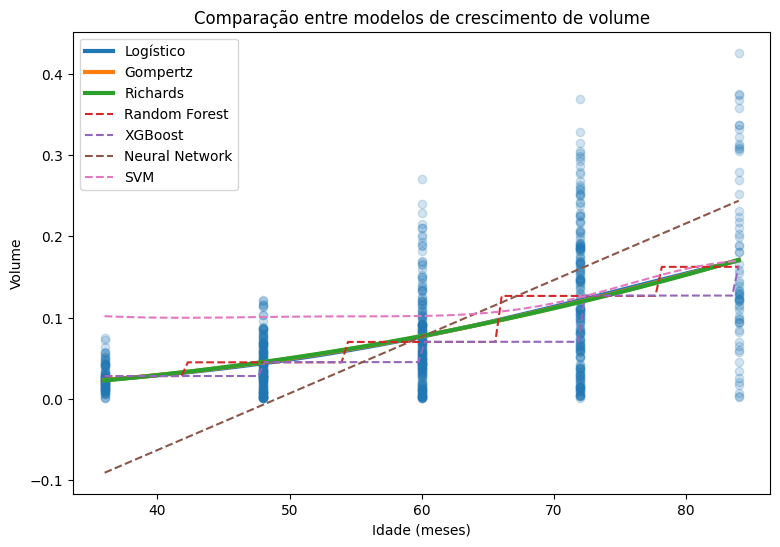

In [227]:
# Gráfico de comparação dos modelos de crescimento volumétrico

plt.figure(figsize=(9,6))

# dados observados
plt.scatter(df["Idade_num"], df["Volume"], alpha=0.2)

# modelos biológicos
plt.plot(t, logistic(t, *params_log), label="Logístico", linewidth=3)
plt.plot(t, gompertz(t, *params_gom), label="Gompertz", linewidth=3)
plt.plot(t, richards(t, *params_rich), label="Richards", linewidth=3)

# modelos de IA
plt.plot(t, pred_rf_curve, label="Random Forest", linestyle="--")
plt.plot(t, pred_xgb_curve, label="XGBoost", linestyle="--")
plt.plot(t, pred_mlp_curve, label="Neural Network", linestyle="--")
plt.plot(t, pred_svm_curve, label="SVM", linestyle="--")

plt.xlabel("Idade (meses)")
plt.ylabel("Volume")

plt.title("Comparação entre modelos de crescimento de volume")

plt.legend()

plt.show()

In [228]:
# ANOVA
modelo = ols('Volume ~ C(Idade_num)', data=df).fit()

anova = sm.stats.anova_lm(modelo)

anova

,df,sum_sq,mean_sq,F,PR(>F)
C(Idade_num),4.0,1.370559,0.342640,80.699862,7.437519e-56
Residual,667.0,2.831984,0.004246,NaN,NaN


In [229]:
# Calcular a proporção da variância explicada

ss_idade = anova["sum_sq"]["C(Idade_num)"]
ss_total = anova["sum_sq"].sum()

variancia_explicada = ss_idade / ss_total

variancia_explicada

np.float64(0.3261261148056281)